# 49. How long a phonon lives in a metal: electron-phonon coupling

In a metal a phonon can decay by lifting an electron from just below the Fermi
level to just above it, so it has a finite lifetime, a linewidth that inelastic
neutron and x-ray scattering resolve, and the same process, summed over all
phonons, is what binds the Cooper pairs of a conventional superconductor. Both
are set by one matrix element, the change of the self-consistent potential under
the displacement, taken between a state at `k` and one at `k + q`.

Here we compute it for fcc aluminium at two wavevectors and read off the
linewidth `gamma` of each mode and its dimensionless coupling `lambda`. Against
Quantum ESPRESSO 7.5 on the same input the frequencies agree to 0.004 cm^-1,
`lambda` to every digit `ph.x` prints and the linewidths to 0.007 GHz.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from defumat import Calculator

PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")
aluminium = Calculator.from_file(CASES / "al-elph-nosym.in", PSEUDO, announce=False)
scf = aluminium.get_scf()
along = aluminium.get_electron_phonon((0.25, 0.0, 0.0), q_cartesian=True)
print("frequencies at q = (1/4, 0, 0) 2pi/a:", np.round(along.frequencies, 3), "cm^-1")

frequencies at q = (1/4, 0, 0) 2pi/a: [ 73.995  73.995 132.474] cm^-1


## The matrix element and the two sums on top of it

The matrix element is

    g_mn(k, q) = < psi_m,k+q | dV_bare + dV_scf | psi_n,k >

for each atom and direction, where `dV_bare` is how the pseudopotential moves
with the atom and `dV_scf` is how the electrons screen it, which is what a
phonon calculation at `q` has already converged. Projected on a mode and summed
over the Fermi surface it gives the linewidth,

    gamma_q,nu = (pi / 2) sum_k w_k sum_mn |z_nu . g_mn|^2 delta(e_nk - E_F) delta(e_m,k+q - E_F)

meaning that only pairs of states that are both at the Fermi level contribute,
and the coupling constant `lambda_q,nu = gamma_q,nu / (pi N(E_F) omega^2)`. The
two deltas are Gaussians of width `sigma`, and since a k-mesh never samples the
Fermi surface exactly, the result is reported at a list of widths, from 0.02 to
0.20 Ry, as `ph.x` does it.

In [2]:
for index in (0, 4):
    sigma = along.sigmas[index]
    print(f"sigma = {sigma:.2f} Ry   N(E_F) = {along.dos[index]:.4f} states/spin/Ry")
    for nu in range(3):
        print(f"   mode {nu + 1}  {along.frequencies[nu]:8.3f} cm^-1   "
              f"gamma = {along.gamma_ghz[index, nu]:6.2f} GHz   lambda = {along.lambdas[index, nu]:.4f}")

sigma = 0.02 Ry   N(E_F) = 2.6758 states/spin/Ry
   mode 1    73.995 cm^-1   gamma =   2.67 GHz   lambda = 0.2120
   mode 2    73.995 cm^-1   gamma =   2.67 GHz   lambda = 0.2120
   mode 3   132.474 cm^-1   gamma =   1.53 GHz   lambda = 0.0381
sigma = 0.10 Ry   N(E_F) = 2.7811 states/spin/Ry
   mode 1    73.995 cm^-1   gamma =   3.89 GHz   lambda = 0.2978
   mode 2    73.995 cm^-1   gamma =   3.89 GHz   lambda = 0.2978
   mode 3   132.474 cm^-1   gamma =  18.17 GHz   lambda = 0.4337


Along `(1/4, 0, 0)` the two transverse modes are degenerate and the third is
longitudinal. At the narrowest width the transverse pair has the larger
linewidth, and since `lambda` divides the linewidth by `omega^2`, the factor of
3.2 between the two frequencies squared makes its coupling more than five times
the longitudinal one. At `sigma = 0.10` Ry the order of the linewidths is the
other way round, 3.89 against 18.17 GHz, which is the first sign that the
narrow end is not to be trusted on this mesh. Let us take a second wavevector of
low symmetry, where all three modes are different.

In [3]:
general = aluminium.get_electron_phonon((0.75, 0.25, 0.25), q_cartesian=True)
print("frequencies at q = (3/4, 1/4, 1/4) 2pi/a:", np.round(general.frequencies, 3), "cm^-1")
print("lambda at sigma = 0.02 Ry:", np.round(general.lambdas[0], 4))

frequencies at q = (3/4, 1/4, 1/4) 2pi/a: [179.849 223.992 292.998] cm^-1
lambda at sigma = 0.02 Ry: [0.1107 0.1604 0.3821]


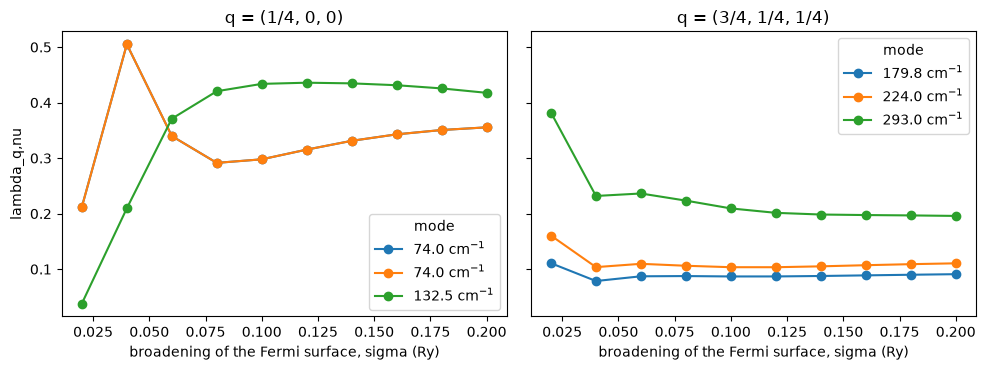

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for axis, result, title in ((axes[0], along, "q = (1/4, 0, 0)"),
                            (axes[1], general, "q = (3/4, 1/4, 1/4)")):
    for nu in range(3):
        axis.plot(result.sigmas, result.lambdas[:, nu], "o-",
                  label=f"{result.frequencies[nu]:.1f} cm$^{{-1}}$")
    axis.set(xlabel="broadening of the Fermi surface, sigma (Ry)", title=title)
    axis.legend(title="mode")
axes[0].set_ylabel("lambda_q,nu")
plt.tight_layout()

On an 8x8x8 grid the Fermi surface is sampled by a few hundred points, and a
Gaussian of 0.02 Ry picks out whichever of them happen to sit within that width
of `E_F`, so at `(1/4, 0, 0)`, where `k` and `k + q` are close and the double
delta weighs few pairs, the narrow end jumps: the transverse `lambda` goes
0.21, 0.51, 0.34 over the first three widths. From about 0.08 Ry on the curves
change slowly, and at `(3/4, 1/4, 1/4)` they settle already from 0.04 Ry. That
plateau is the regime where the mesh resolves the broadened Fermi surface, at
the price that the broadening is now wide enough to smear the band structure
itself. In practice one takes a denser k-mesh and looks for the plateau to
extend down to small `sigma`; the value on the plateau is the one to quote.

In [5]:
rows = [("frequency, mode 1 (cm^-1)", along.frequencies[0], 73.9956),
        ("frequency, mode 3 (cm^-1)", along.frequencies[2], 132.4752),
        ("N(E_F) at sigma 0.02 (states/spin/Ry)", along.dos[0], 2.675810),
        ("gamma, mode 1, sigma 0.04 (GHz)", along.gamma_ghz[1, 0], 6.42),
        ("lambda, mode 1, sigma 0.04", along.lambdas[1, 0], 0.5050),
        ("lambda, mode 2 at (3/4,1/4,1/4), sigma 0.02", general.lambdas[0, 1], 0.1604)]
print(f"{'':46s}{'here':>12s}{'ph.x 7.5':>12s}")
for name, ours, theirs in rows:
    print(f"{name:46s}{ours:12.4f}{theirs:12.4f}")

                                                      here    ph.x 7.5
frequency, mode 1 (cm^-1)                          73.9950     73.9956
frequency, mode 3 (cm^-1)                         132.4738    132.4752
N(E_F) at sigma 0.02 (states/spin/Ry)               2.6758      2.6758
gamma, mode 1, sigma 0.04 (GHz)                     6.4157      6.4200
lambda, mode 1, sigma 0.04                          0.5050      0.5050
lambda, mode 2 at (3/4,1/4,1/4), sigma 0.02         0.1604      0.1604


The reference is `ph.x` from Quantum ESPRESSO 7.5 with
`electron_phonon = 'simple'` on the same input, without symmetry. Quantum
ESPRESSO's own test suite has this cell at the first of these wavevectors, but
its stored output was written by version 6.5, whose frequencies there are 2.5
cm^-1 higher from an identical ground state, so it is not the comparison used
here.

The checks against both reference outputs, at all ten broadenings, are in
`tests/regression/test_electron_phonon.py`.